In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings as warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Housing.csv')

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

# EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


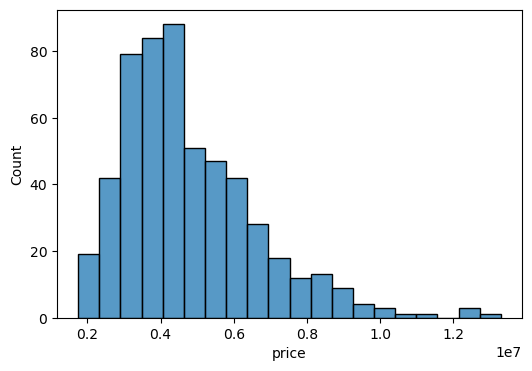

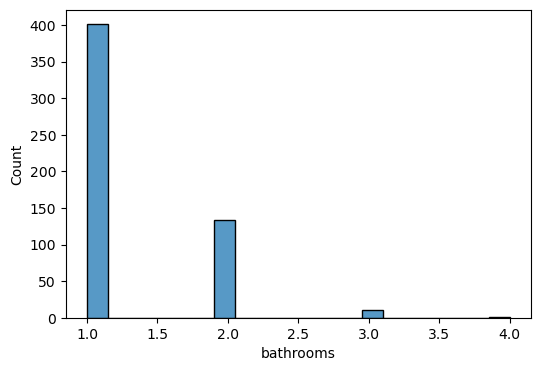

In [7]:
numeric_columns=['price','bathrooms']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],bins=20)

<Axes: >

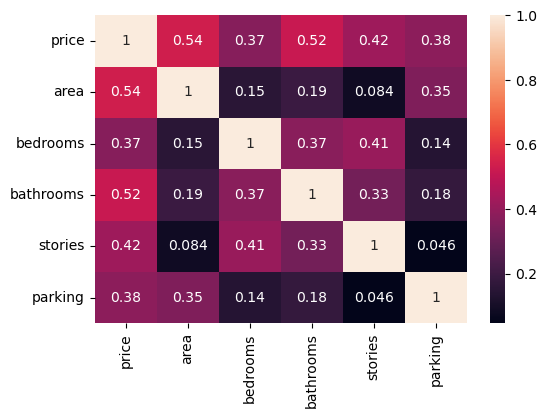

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='mainroad', ylabel='price'>

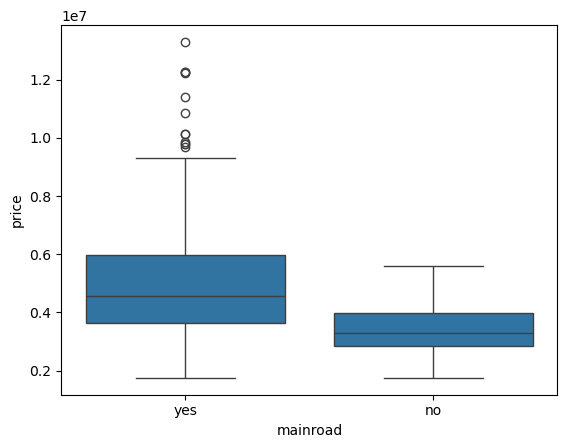

In [9]:
sns.boxplot(x='mainroad', y='price', data=df)

<Axes: xlabel='hotwaterheating', ylabel='price'>

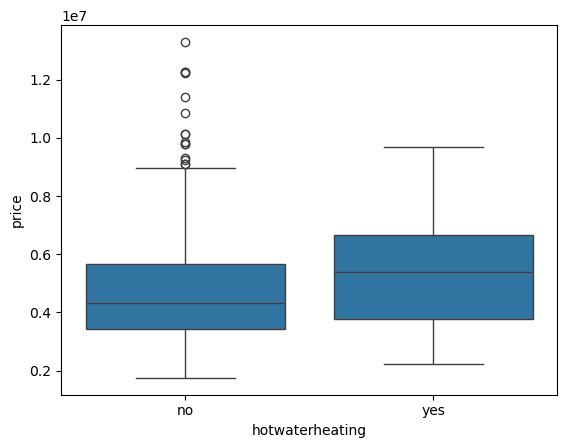

In [10]:
sns.boxplot(x='hotwaterheating', y='price', data=df)

# Data Cleaning and preprocessing

In [11]:
df.shape

(545, 13)

In [12]:
df_encode=pd.get_dummies(df,drop_first=True)

In [13]:
df_encode.shape

(545, 14)

In [14]:
df_encode.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [15]:
df_encode=df_encode.astype(int)

In [16]:
df_encode.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [17]:
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()

In [18]:
df_encode.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

In [19]:
columns=['area','bedrooms','bathrooms','stories','parking']
df_encode[columns]=Scaler.fit_transform(df_encode[columns])

In [20]:
df_encode.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,1.046726,1.403419,1.421812,1.378217,1.517692,1,0,0,0,1,1,0,0
1,12250000,1.757010,1.403419,5.405809,2.532024,2.679409,1,0,0,0,1,0,0,0
2,12250000,2.218232,0.047278,1.421812,0.224410,1.517692,1,0,1,0,0,1,1,0
3,12215000,1.083624,1.403419,1.421812,0.224410,2.679409,1,0,1,0,1,1,0,0
4,11410000,1.046726,1.403419,-0.570187,0.224410,1.517692,1,1,1,0,1,0,0,0


In [21]:

from scipy.stats import chi2_contingency

# Assume df is your DataFrame
# Step 1: Bin the continuous target 'price'
df_encode['price_bin'] = pd.qcut(df_encode['price'], q=3, labels=['Low','Medium','High'])

# Step 2: Define categorical features
categorical_features = [
    'mainroad_yes','guestroom_yes','basement_yes',
    'hotwaterheating_yes','airconditioning_yes',
    'prefarea_yes','furnishingstatus_semi-furnished',
    'furnishingstatus_unfurnished'
]

# Step 3: Run Chi-square test
results = []
for col in categorical_features:
    contingency = pd.crosstab(df_encode[col], df_encode['price_bin'])
    chi2, p, dof, ex = chi2_contingency(contingency)
    decision = 'Keep' if p < 0.05 else 'Remove'
    results.append([col, chi2, p, decision])

# Step 4: Convert to DataFrame for neat output
chi_results = pd.DataFrame(results, columns=['Feature','Chi-square','p-value','Decision'])
print(chi_results)


                           Feature  Chi-square       p-value Decision
0                     mainroad_yes   54.161569  1.733663e-12     Keep
1                    guestroom_yes   54.368229  1.563468e-12     Keep
2                     basement_yes   31.113195  1.753298e-07     Keep
3              hotwaterheating_yes    4.083423  1.298063e-01   Remove
4              airconditioning_yes  102.838261  4.666115e-23     Keep
5                     prefarea_yes   69.362981  8.670017e-16     Keep
6  furnishingstatus_semi-furnished   44.833379  1.838888e-10     Keep
7     furnishingstatus_unfurnished   91.566283  1.308080e-20     Keep


In [122]:
finaldf = df_encode[['price', 'area', 'bedrooms', 'bathrooms',  'parking',
       'mainroad_yes','airconditioning_yes','prefarea_yes','stories',
       ]]


# Feature Engineering

# Model


In [123]:
from sklearn.model_selection import train_test_split

In [124]:
X=finaldf.drop('price',axis=1)

In [125]:
y=finaldf['price']

In [144]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.50,random_state=42)

In [145]:
X_train.shape

(272, 8)

In [146]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [147]:
y_pred=model.predict(X_test)

In [148]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.6408062408007188